In [1]:
import pandas as pd

df = pd.read_csv("data/ai_job_dataset.csv")

df = df.dropna(subset=["salary_usd", "job_title"])
df["company_location"] = df["company_location"].str.strip().str.title()
df["experience_level"] = df["experience_level"].str.strip()
df["salary_usd"] = pd.to_numeric(df["salary_usd"])

df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [2]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="user",
    database="job_market"
)
cursor = conn.cursor()
print("Connected!")

Connected!


In [3]:
cursor.execute("DROP TABLE IF EXISTS jobs")

cursor.execute("""
    CREATE TABLE jobs (
        job_id VARCHAR(10),
        job_title VARCHAR(100),
        salary_usd FLOAT,
        experience_level VARCHAR(10),
        company_location VARCHAR(100),
        required_skills VARCHAR(255),
        industry VARCHAR(100),
        remote_ratio INT
    )
""")
print("Table created!")

Table created!


In [4]:
for _, row in df.iterrows():
    cursor.execute(
        "INSERT INTO jobs (job_id, job_title, salary_usd, experience_level, company_location, required_skills, industry, remote_ratio) VALUES (%s, %s, %s, %s, %s, %s, %s, %s)",
        (row["job_id"], row["job_title"], row["salary_usd"], row["experience_level"], row["company_location"], row["required_skills"], row["industry"], row["remote_ratio"])
    )

conn.commit()
print("Data inserted!")

Data inserted!


In [5]:
cursor.execute("SELECT COUNT(*) FROM jobs")
print(cursor.fetchone())

cursor.execute("SELECT * FROM jobs LIMIT 5")
for row in cursor.fetchall():
    print(row)

(15000,)
('AI00001', 'AI Research Scientist', 90376.0, 'SE', 'China', 'Tableau, PyTorch, Kubernetes, Linux, NLP', 'Automotive', 50)
('AI00002', 'AI Software Engineer', 61895.0, 'EN', 'Canada', 'Deep Learning, AWS, Mathematics, Python, Docker', 'Media', 100)
('AI00003', 'AI Specialist', 152626.0, 'MI', 'Switzerland', 'Kubernetes, Deep Learning, Java, Hadoop, NLP', 'Education', 0)
('AI00004', 'NLP Engineer', 80215.0, 'SE', 'India', 'Scala, SQL, Linux, Python', 'Consulting', 50)
('AI00005', 'AI Consultant', 54624.0, 'EN', 'France', 'MLOps, Java, Tableau, Python', 'Media', 100)


In [6]:
cursor.execute("""
    SELECT experience_level, AVG(salary_usd) 
    FROM jobs 
    GROUP BY experience_level
""")
for row in cursor.fetchall():
    print(row)

('SE', 122187.65784549585)
('EN', 63133.377084454005)
('MI', 87955.47183284846)
('EX', 187723.64734042552)


In [7]:
from collections import Counter

cursor.execute("SELECT required_skills FROM jobs")
all_skills = []
for row in cursor.fetchall():
    skills = [s.strip() for s in row[0].split(",")]
    all_skills.extend(skills)

skill_counts = Counter(all_skills)
print(skill_counts.most_common(10))

[('Python', 4450), ('SQL', 3407), ('TensorFlow', 3022), ('Kubernetes', 3009), ('Scala', 2794), ('PyTorch', 2777), ('Linux', 2705), ('Git', 2631), ('Java', 2578), ('GCP', 2442)]


In [8]:
cursor.execute("""
    SELECT remote_ratio, AVG(salary_usd)
    FROM jobs
    GROUP BY remote_ratio
    ORDER BY remote_ratio
""")
for row in cursor.fetchall():
    print(row)

(0, 114140.23113300493)
(50, 115776.8067932068)
(100, 116160.54593495934)


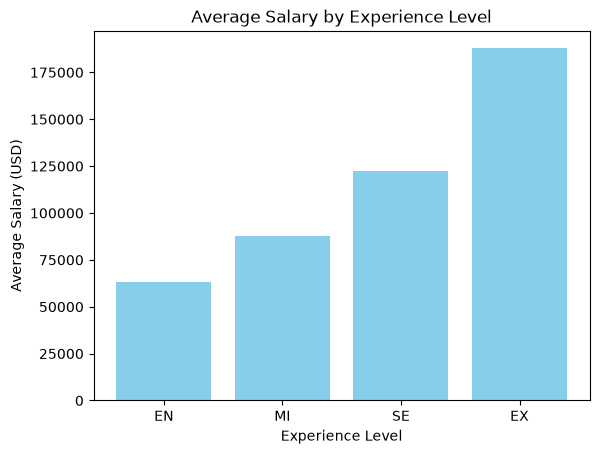

In [20]:
import matplotlib.pyplot as plt

levels = ["EN", "MI", "SE", "EX"]
salaries = [63133, 87955, 122188, 187724]

plt.bar(levels, salaries, color="skyblue")
plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")
plt.savefig("salary_by_experience.png")
plt.show()

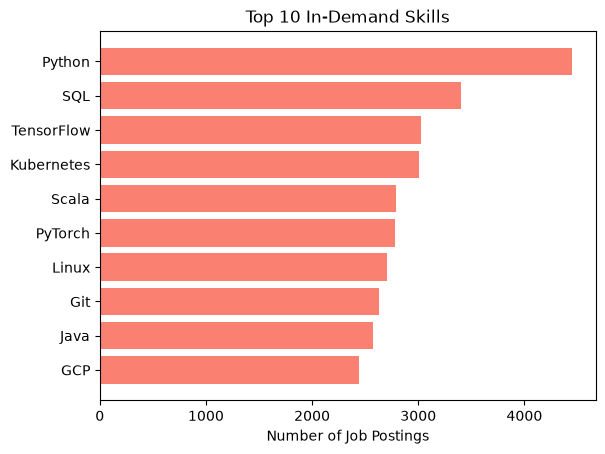

In [22]:
skills = ["Python", "SQL", "TensorFlow", "Kubernetes", "Scala", "PyTorch", "Linux", "Git", "Java", "GCP"]
counts = [4450, 3407, 3022, 3009, 2794, 2777, 2705, 2631, 2578, 2442]

plt.barh(skills, counts, color="salmon")
plt.title("Top 10 In-Demand Skills")
plt.xlabel("Number of Job Postings")
plt.gca().invert_yaxis()
plt.savefig("top_in_demand_skills.png")
plt.show()

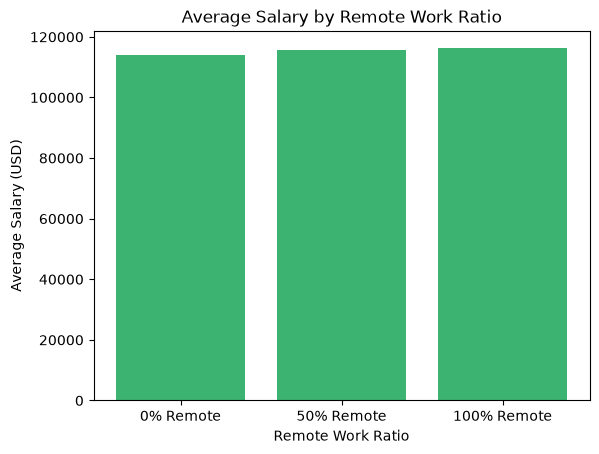

In [11]:
labels = ["0% Remote", "50% Remote", "100% Remote"]
avg_salaries = [114140, 115777, 116161]

plt.bar(labels, avg_salaries, color="mediumseagreen")
plt.title("Average Salary by Remote Work Ratio")
plt.xlabel("Remote Work Ratio")
plt.ylabel("Average Salary (USD)")
plt.show()

In [13]:
cursor.close()
conn.close()